# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [9]:
from keras.datasets import fashion_mnist

from keras.models import Sequential
from keras.layers import Input
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import GlobalAveragePooling2D
from keras.layers import Flatten
from keras.layers import Dense

"""
Оптимизаторы
SGD  - Стохастический градиентный спуск
Adam - Как градиентный спуск, шаг адаптируется автоматически
"""
# from keras.optimizers import SGD
from keras.optimizers import Adam

"""
Предобработка
to_categorical - сабитовая маска для классов: 1/3 - [1,0,0]...
это нужно для определения вероятностей
[0.73, 0.12, ...]
"""
from keras.utils import to_categorical

from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy             as np

## 1.2. Подготовка исходных данных

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: X =  (60000, 28, 28)
Test:  X =  (10000, 28, 28)


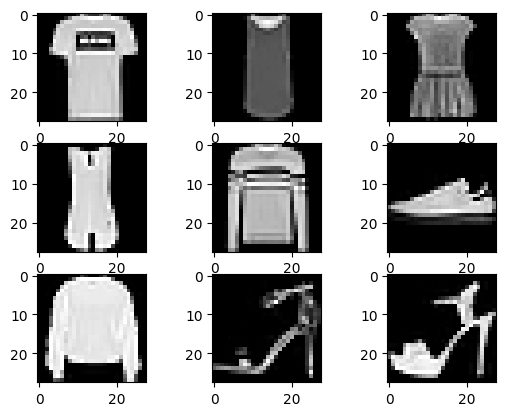

In [10]:
# Разделяем данные на обучающую и тестовую выборку
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test:  X = ',  testX.shape)

y_train_cat = to_categorical(trainy, 10)
y_test_cat  = to_categorical(testy,  10)

# Визуализируем часть данных из датасета
for i in range(1, 10):
    plt.subplot(3, 3, i) # сетка 3х3
    plt.imshow(trainX[i],
               cmap = 'gray') # colormap
plt.show()

## 1.3. Архитектура нейронной сети

In [11]:
"""
kernel_size      - размер фильтра
PADDING = 'same' - Рамка из нулей, чтобы выход был 28×28, а не 26×26

pool_size   - размер фильтра для пулинга
strides = 2 - сдвигаемся на 2 → выход ровно вдвое меньше: 28×28 → 14×14
"""
kernel_size = (3,3)
padding   = 'same'
pool_size = (2,2)
strides   = 2
IMG_SIZE  = 28
CHANNELS  = 1

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),

    # Извлечение признаков (самых мелких)
    Conv2D(filters     = 32,
           kernel_size = kernel_size,
           padding     = padding,
           activation  = 'relu'
    ),
    MaxPooling2D(pool_size = pool_size,
                 strides   = strides
    ),

    # Опять извлечение признаков (более сложных).
    # Сначала низкоуровневые - линии
    # А потом - более сложные комбинации - условно: воротник, манжет и т.д.

    # Для чего увеличиваем кол-во фильтров, если изображение и так уже уменьшено после пулинга?
    # Пример:
    # Уровень 1 (буквы): а, б, в, г... — всего 33 варианта → мало фильтров
    # Уровень 2 (слова): стол, стул, диван, шкаф... — тысячи вариантов → много фильтров

    Conv2D(filters     = 64,
           kernel_size = kernel_size,
           padding     = padding,
           activation  = 'relu'
    ),
    MaxPooling2D(pool_size = pool_size,
                 strides   = strides
    ),

    # вытягиваем в колбаску (вектор)
    # Flatten(), # тут 1568 признаков

    # Собственно классификация
    GlobalAveragePooling2D(),
    Dense(units      = 128,
          activation = 'relu'),  # сжимаем эти 1568 признаков в 128 : типа осмысливаем эти признаки
    Dense(units      = 10,  # а здесь уже жестко распределяем по 10 классам
          activation ='softmax') # cо значениями, больше похожими на вероятность [0, 1]
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

## 1.4. Компиляция модели и внедрение callback`ов

In [12]:
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy', # формула штрафа за неверное предсказание:
                                            # берем, потому что у нас разбито по категориям
    metrics   = ['accuracy']      # точность
)

checkpoint = ModelCheckpoint(
    filepath       = 'my_first_cnn.keras',
    monitor        = 'val_accuracy', # отслеживаем точность на валидации
    save_best_only = True,
    verbose        = 1 # логи
)

early_stop = EarlyStopping(
    monitor  = 'val_loss', # Следим именно за val_loss, а не за val_accuracy —
                        # потому что loss точнее отражает реальное ухудшение.
                        # Accuracy может не меняться

    patience = 3,       # сколько эпох ждём
    restore_best_weights = True, # откатываемся к лучшим весам
    verbose  = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  ='val_loss',
    factor   = 0.5, # во сколько уменьшаем (но вообще-то правильнее увеличиваем) learning_rate
    patience = 3,
    min_lr   = 1e-6, # нижняя граница learning_rate
    verbose  = 1
)

CALLBACKS = [checkpoint, early_stop, reduce_lr]


## 1.5 Обучение модели

In [13]:
EPOCHS = 30
his = model.fit(
    trainX,
    y_train_cat, # метки классов по которым надо распределить
    batch_size = 32, # обрабатываем по 32 картинки
    epochs     = EPOCHS,
    validation_split = 0.2, # 20% картинок для валидации
    callbacks  = CALLBACKS
)


model.evaluate(testX, y_test_cat) # метод evaluate() предназначен для оценки уже обученной модели с использованием данных проверки
                                  # (или тестирования) и соответствующих меток. Возвращает значение потерь и значения показателей для модели.

Epoch 1/30
1491/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5969 - loss: 1.5524
Epoch 1: val_accuracy improved from None to 0.80900, saving model to my_first_cnn.keras

Epoch 1: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7219 - loss: 0.8557 - val_accuracy: 0.8090 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 2/30
1489/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8240 - loss: 0.5027
Epoch 2: val_accuracy improved from 0.80900 to 0.83108, saving model to my_first_cnn.keras

Epoch 2: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8317 - loss: 0.4802 - val_accuracy: 0.8311 - val_loss: 0.4786 - learning_rate: 0.0010
Epoch 3/30
1494/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8490 - loss: 0.4239
Epoch 3: val_accuracy improved from 0.83108 to 0.85000, saving model to my_first_cnn.keras

Epoch 3: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━

[0.30298683047294617, 0.8949999809265137]

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

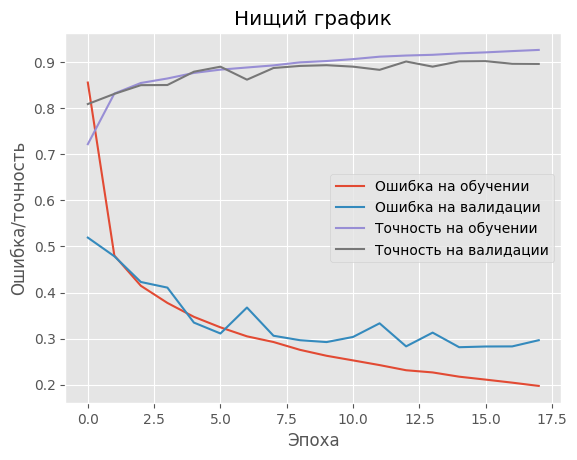

In [14]:
N = np.arange(0, len(his.history["loss"])) # массив эпох

plt.style.use("ggplot")
plt.figure()
plt.plot(N, his.history["loss"], label="Ошибка на обучении")
plt.plot(N, his.history["val_loss"], label="Ошибка на валидации")
plt.plot(N, his.history["accuracy"], label="Точность на обучении")
plt.plot(N, his.history["val_accuracy"], label="Точность на валидации")
plt.title("Нищий график")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



### 1.7.1 Загрузка изображений

In [15]:
# Скачиваем архив с набором данных
!curl -L -o clothes_dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/ryanbadai/clothes-dataset


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1405M  100 1405M    0     0  14.0M      0  0:01:40  0:01:40 --:--:-- 15.2M


In [16]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip clothes_dataset.zip -d new_dataset

### 1.7.2 Выбор изображений для модели

In [17]:
import os
from glob import glob

base_dir = '/content/new_dataset/Clothes_Dataset'

kaggle_classes = ['Polo', 'Jeans', 'Hoodie', 'Kemeja', 'Jaket']

image_paths = []
true_labels = []

for cls in kaggle_classes:
    folder = os.path.join(base_dir, cls)
    files = sorted(glob(os.path.join(folder, '*'))) #  сортируем все файлы в папке класса
    if not files:
        continue
    image_paths.append(files[0]) # первый файл из папки
    true_labels.append(cls)      # его метка = имя папки

len(image_paths)
image_paths

['/content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg',
 '/content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg',
 '/content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg',
 '/content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg',
 '/content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg']

### 1.7.3 Преобработка изображений

In [18]:
from PIL import Image

def preprocess_image(path):
    img = Image.open(path).convert('L')      # в оттенки серого
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype('float32') # в numpy-массив и в удобный для кераса тип числа
    arr = (255.0 - arr) / 255.0   # сначала инвертируем, потом нормализуем

    arr = arr.reshape(IMG_SIZE, IMG_SIZE, CHANNELS)
    return arr

X_new = np.stack([preprocess_image(p) for p in image_paths], # преобразуем каждое изображение
                 axis=0) # каждое изображение добавляется как новая строка
X_new.shape


(5, 28, 28, 1)

### 1.7.4 Метки классов

In [19]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

### 1.7.5 Предсказания модели

In [20]:
probs = model.predict(X_new)
pred_indices = np.argmax(probs, axis=1) # ищет максимум по строке (по классам), а не по столбцу. Берет максимальную вероятность

for true_label, pred_idx in zip(true_labels, pred_indices):
    print('Класс из нашего датасета:', true_label)
    print('Предсказание модели по Fashion-MNIST:', class_names[pred_idx], "\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
Класс из нашего датасета: Polo
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Jeans
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Hoodie
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Kemeja
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Jaket
Предсказание модели по Fashion-MNIST: Dress 



### 1.7.6 Визуализируем предсказания

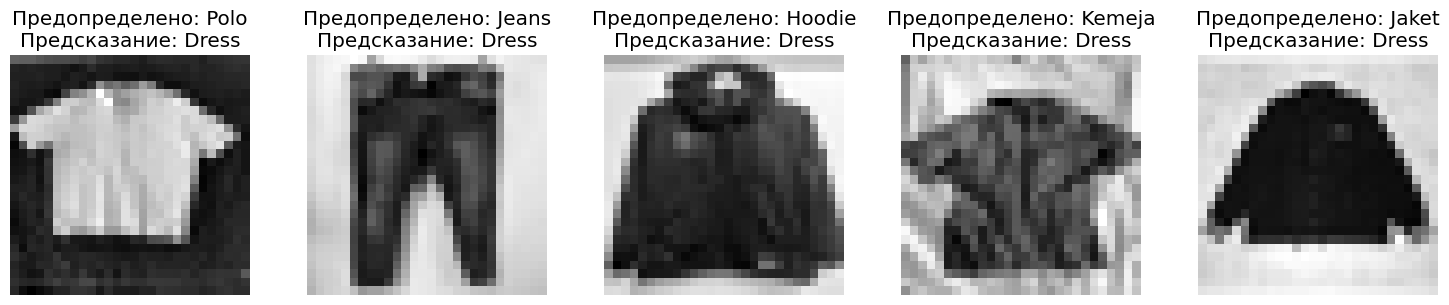

In [21]:
plt.figure(figsize=(15, 3))

for i, (path, true_label, pred_idx) in enumerate(zip(image_paths, true_labels, pred_indices)): # zip объединяет три списка в тройки (путь, истина, индекс), enumerate добавляет счётчик i для позиции subplot.
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE)) # заново открываем оригинальную фотку
    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Предопределено: {true_label}\nПредсказание: {class_names[pred_idx]}')

plt.tight_layout()
plt.show()


# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**

In [22]:
!mkdir -p data
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0  11.2M      0  0:00:19  0:00:19 --:--:-- 13.4M


In [23]:
!unzip -q -o data/flowers_dataset.zip -d data/flowers_dataset

In [24]:
!ls data/flowers_dataset/flower_photos
DATASET_PATH = "data/flowers_dataset/flower_photos"

daisy  dandelion  roses  sunflowers  tulips


In [25]:
from sklearn.model_selection import train_test_split

IMG_SIZE = 128
BATCH_SIZE = 32

X, y = [], []

for idx, cls in enumerate(os.listdir(DATASET_PATH)):
    cls_folder = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_folder):
        continue
    for fname in os.listdir(cls_folder):
        fpath = os.path.join(cls_folder, fname)
        try:
            img = Image.open(fpath).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            arr = np.array(img).astype('float32') / 255.0
            # arr = arr.reshape(IMG_SIZE, IMG_SIZE, 3)
            X.append(arr)
            y.append(idx)
        except:
            continue

X = np.array(X)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # сид и это оказывается мемное число
    stratify=y  # сохраняет пропорции классов
)


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [26]:
from keras.layers import SeparableConv2D

flowers_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        # kernel_regularizer=l2(1e-4)
    ),

    Dense(5, activation='softmax')
])

flowers_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
flowers_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "flowers_cnn_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

EPOCHS = 30

history = flowers_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stopping, reduce_lr]
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3015 - loss: 1.5070
Epoch 1: val_accuracy improved from None to 0.47275, saving model to flowers_cnn_best.keras

Epoch 1: finished saving model to flowers_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.3743 - loss: 1.3993 - val_accuracy: 0.4728 - val_loss: 1.2479 - learning_rate: 0.0010
Epoch 2/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4598 - loss: 1.2318
Epoch 2: val_accuracy improved from 0.47275 to 0.49319, saving model to flowers_cnn_best.keras

Epoch 2: finished saving model to flowers_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4806 - loss: 1.2058 - val_accuracy: 0.4932 - val_loss: 1.1287 - learning_rate: 0.0010
Epoch 3/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5360 - loss: 1.1146
Epoch 3: val_accuracy improved from 0.49319 to 0.53815, saving model to flowers_cnn_best.keras

Epoch 3: finished saving model to flowers_cnn_best.keras
92/92 ━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7507 - loss: 0.6514


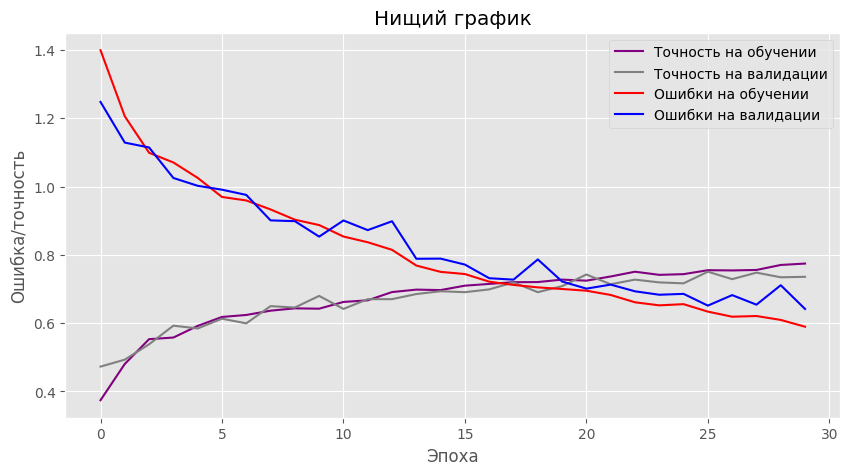

In [28]:
val_loss, val_acc = flowers_model.evaluate(X_val, y_val)


plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"],     label="Точность на обучении",  color='purple')
plt.plot(history.history["val_accuracy"], label="Точность на валидации", color='gray')
plt.plot(history.history["loss"],         label="Ошибки на обучении",    color='red')
plt.plot(history.history["val_loss"],     label="Ошибки на валидации",   color='blue')

plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.title("Нищий график")
plt.legend()
plt.show()



## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [79]:
NUM_CLASSES = 5
IMG_SIZE = 128
BATCH_SIZE = 32
alexnet = Sequential([
    Conv2D(filters=96,
           kernel_size=(11, 11),
           strides=2,
           activation='relu',
           input_shape=(IMG_SIZE, IMG_SIZE, 3),
           padding='same'),

    Conv2D(filters = 256,
           kernel_size=(5,5),
           activation='relu',
           padding='same'),

    MaxPooling2D(pool_size=(3,3),
                 strides=2),

    Conv2D(filters = 384,
           kernel_size=(3,3),
           activation='relu',
           padding='same'),

    MaxPooling2D(pool_size=(3,3),
                 strides=2),

    Conv2D(filters = 384,
           kernel_size=(3,3),
           activation='relu',
           padding='same'),
    Conv2D(filters = 384,
           kernel_size=(3,3),
           activation='relu',
           padding='same'),

    Conv2D(filters=256,
           kernel_size=(3,3),
           activation='relu',
           padding='same'),
    MaxPooling2D(pool_size=(3,3),
                 strides=2),

GlobalAveragePooling2D(),
    Dense(2048, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(256, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

alexnet.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 31, 31, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 15, 15, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 15, 15, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 15, 15, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 15, 15, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2048)           │       526,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,962,885 (30.38 MB)

 Trainable params: 7,962,885 (30.38 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        'best_alexnet.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [81]:
alexnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 35

history = alexnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/35
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2207 - loss: 1.6284
Epoch 1: val_loss improved from None to 1.60016, saving model to best_alexnet.keras

Epoch 1: finished saving model to best_alexnet.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.2377 - loss: 1.6090 - val_accuracy: 0.2452 - val_loss: 1.6002 - learning_rate: 0.0010
Epoch 2/35
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2420 - loss: 1.6013
Epoch 2: val_loss did not improve from 1.60016
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.2415 - loss: 1.6044 - val_accuracy: 0.2452 - val_loss: 1.6013 - learning_rate: 0.0010
Epoch 3/35
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2408 - loss: 1.6018
Epoch 3: val_loss did not improve from 1.60016
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.2446 - loss: 1.6023 - val_accuracy: 0.2452 - val_loss: 1.6013 - learning_rate: 0.0010
Epoch 4/35
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.2471 - loss: 1.601

In [82]:
val_loss, val_acc = alexnet.evaluate(X_val, y_val)
print(f"Validation accuracy: {val_acc:.3f}, Validation loss: {val_loss:.3f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6853 - loss: 0.8124
Validation accuracy: 0.685, Validation loss: 0.812


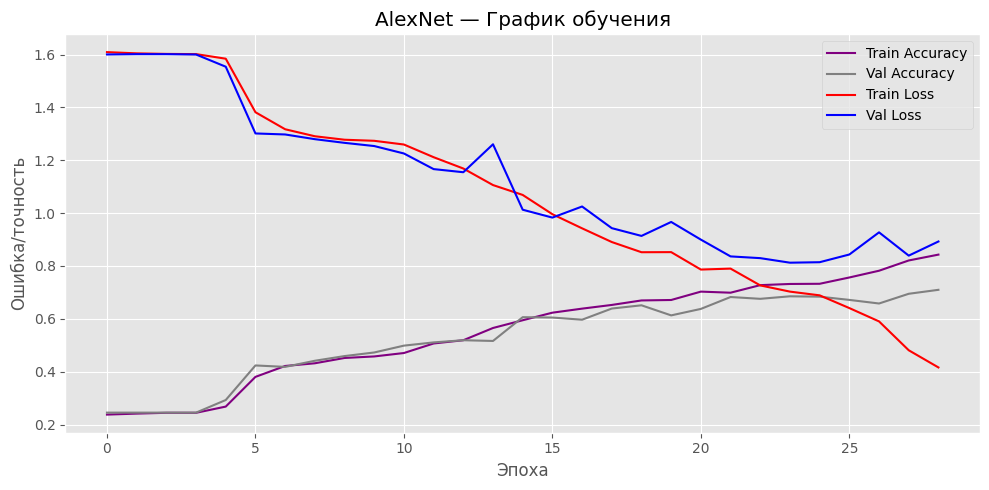

In [83]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy", color='purple')
plt.plot(history.history["val_accuracy"], label="Val Accuracy", color='gray')
plt.plot(history.history["loss"], label="Train Loss", color='red')
plt.plot(history.history["val_loss"], label="Val Loss", color='blue')

plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.title("AlexNet — График обучения")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.3. Сохраните полученные модели

## 2.4. Загрузите обученную модель из прошлой практической работы



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [84]:
import random
import cv2
from tensorflow.keras.models import load_model


classifier = load_model('classifier.h5')

# 15 рандомных фото
all_images = glob(os.path.join(DATASET_PATH, "*", "*.*"))
random.seed(42)
sample_paths = random.sample(all_images, 15)

# маппинг классов
cnn_classes = [
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
]
cnn_indices = {cls: i for i, cls in enumerate(cnn_classes)}

clf_classes = sorted([
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])
clf_indices = {cls: i for i, cls in enumerate(clf_classes)}

# загружаем батчи
def load_batch_cnn(paths, size):
    X, y = [], []
    for p in paths:
        cls = os.path.basename(os.path.dirname(p))
        img = Image.open(p).convert('RGB').resize(size)
        arr = np.array(img).astype('float32') / 255.0
        X.append(arr)
        y.append(cnn_indices[cls])
    return np.stack(X), np.array(y)

# батчи для простой полносвязной нейронки
def load_batch_flat(paths, size=(64, 64)):
    X, y = [], []
    for p in paths:
        cls = os.path.basename(os.path.dirname(p))
        img = cv2.imread(p)
        img = cv2.resize(img, size)
        arr = img.astype('float32') / 255.0
        arr = arr.reshape(-1)            # (12288,)
        X.append(arr)
        y.append(clf_indices[cls])
    return np.stack(X), np.array(y)

X_flowers,    y_true_cnn = load_batch_cnn(sample_paths, flowers_model.input_shape[1:3])
X_alexnet,    _          = load_batch_cnn(sample_paths, alexnet.input_shape[1:3])
X_classifier, y_true_clf = load_batch_flat(sample_paths)

# предсказываем
pred_flowers    = np.argmax(flowers_model.predict(X_flowers,    verbose=0), axis=1)
pred_alexnet    = np.argmax(alexnet.predict(X_alexnet,          verbose=0), axis=1)
pred_classifier = np.argmax(classifier.predict(X_classifier,   verbose=0), axis=1)


print(f"flowers_model accuracy : {np.mean(pred_flowers    == y_true_cnn):.3f}")
print(f"AlexNet accuracy       : {np.mean(pred_alexnet    == y_true_cnn):.3f}")
print(f"classifier accuracy    : {np.mean(pred_classifier == y_true_clf):.3f}")


print(f"\n{'#':<3} {'файл':<25} {'истина':<12} {'flowers':<12} {'alexnet':<12} {'classifier':<12}")
print("-" * 80)
for i, path in enumerate(sample_paths):
    print(f"{i+1:<3} {os.path.basename(path)[:24]:<25} "
          f"{cnn_classes[y_true_cnn[i]]:<12} "
          f"{cnn_classes[pred_flowers[i]]:<12} "
          f"{cnn_classes[pred_alexnet[i]]:<12} "
          f"{clf_classes[pred_classifier[i]]:<12}")


flowers_model accuracy : 0.867
AlexNet accuracy       : 0.800
classifier accuracy    : 0.533

#   файл                      истина       flowers      alexnet      classifier  
--------------------------------------------------------------------------------
1   9610373158_5250bce6ac_n.  sunflowers   sunflowers   sunflowers   sunflowers  
2   3265902330_d8b1e44545.jp  roses        roses        roses        dandelion   
3   5961803532_9368212949_m.  roses        roses        roses        tulips      
4   4606893762_c2f26c7e91_n.  dandelion    dandelion    dandelion    dandelion   
5   14088053307_1a13a0bf91_n  daisy        sunflowers   tulips       dandelion   
6   14330343061_99478302d4_m  daisy        daisy        daisy        dandelion   
7   305160642_53cde0f44f.jpg  daisy        roses        daisy        daisy       
8   319298955_0c72bd36bf.jpg  roses        roses        roses        tulips      
9   2542908888_25a1c78ff0.jp  dandelion    dandelion    daisy        daisy       
10  7

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [85]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [86]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [87]:

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

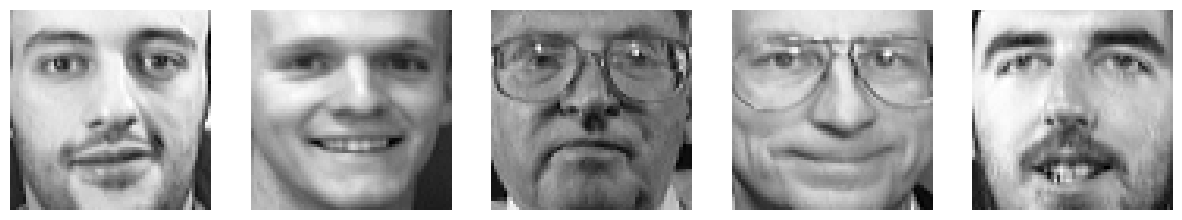

In [88]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [89]:
n_pixels = train.shape[1]

X_train = train[:, :(n_pixels + 1) // 2, :]
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [90]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

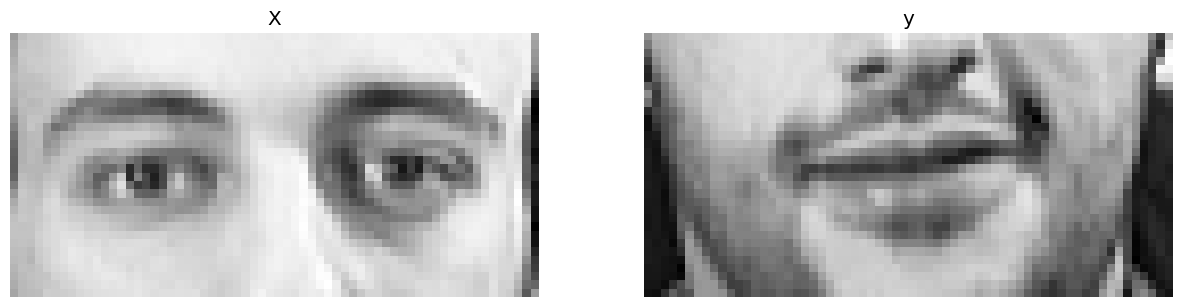

In [91]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [92]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [93]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

faces_model = Sequential([
    Flatten(input_shape=(32, 64)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(2048, activation='sigmoid')  # 32*64 выходных пикселей
])

faces_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2048)           │       526,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,706,752 (6.51 MB)

 Trainable params: 1,706,752 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [94]:

from keras.optimizers import Adam

faces_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [95]:
EPOCHS = 100
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history_faces = faces_model.fit(
    X_train,
    y_train_n,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0261 - mae: 0.1310 - val_loss: 0.0232 - val_mae: 0.1239 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0212 - mae: 0.1175 - val_loss: 0.0217 - val_mae: 0.1191 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0204 - mae: 0.1153 - val_loss: 0.0214 - val_mae: 0.1193 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0202 - mae: 0.1150 - val_loss: 0.0217 - val_mae: 0.1187 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0199 - mae: 0.1135 - val_loss: 0.0211 - val_mae: 0.1171 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0192 - mae: 0.1116 - val_loss: 0.0200 - val_mae: 0.1141 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0186 - mae: 0.1094 - val_loss: 0.0190 - val_mae: 0.1112 - learning_rate: 0.0010
Epoch 8/100
8/8 ━━━━

## 3.5. Сделайте предсказания на тестовых данных

In [96]:

preds = faces_model.predict(X_test)
print(preds.shape)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step
(80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [97]:

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_n, preds)
print(f"Mean Absolute Error (MAE) на тесте: {mae:.4f}")


Mean Absolute Error (MAE) на тесте: 0.0884


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [98]:

pred_test = preds.reshape(preds.shape[0], 32, 64)
print("Форма pred_test:", pred_test.shape)


Форма pred_test: (80, 32, 64)


Отрисуйте все предсказания.

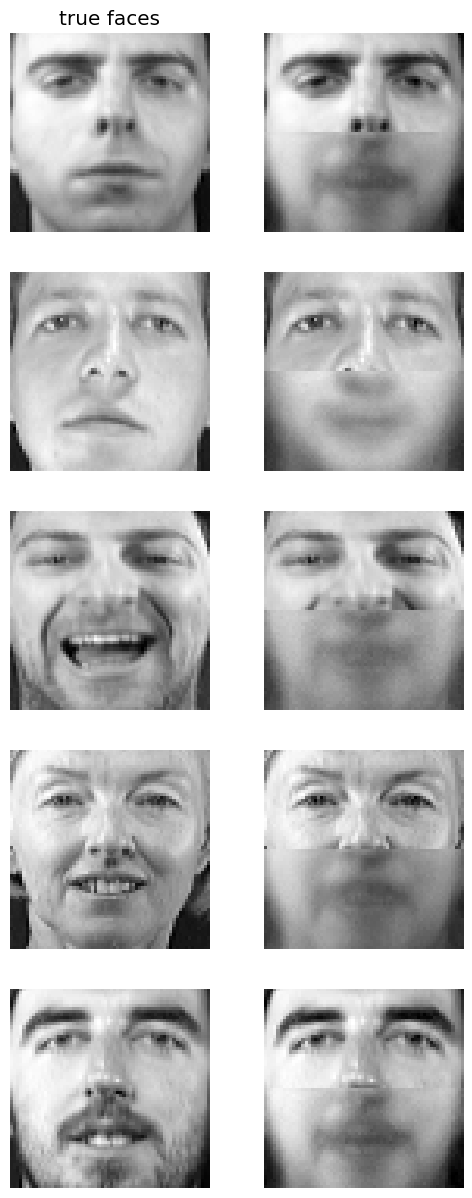

In [99]:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step


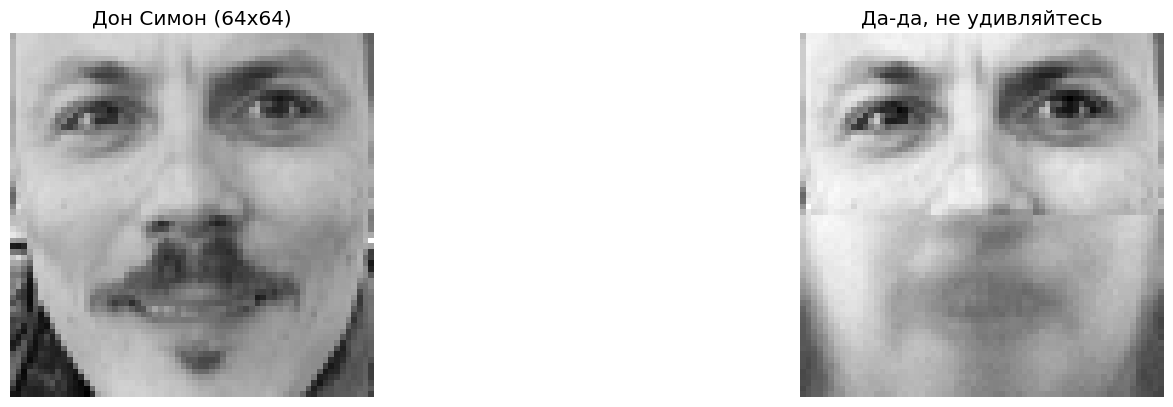

In [101]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/face.jpg"

IMGSIZE = 64

img = Image.open(img_path).convert("L")          # grayscale
img = img.resize((IMGSIZE, IMGSIZE))             # 64x64
img_arr = np.array(img).astype("float32") / 255.

upper_half = img_arr[:32, :]                     # (32, 64)
upper_half_input = upper_half.reshape(1, 32, 64) # батч из 1 картинки

pred_vec = faces_model.predict(upper_half_input)[0]   # (2048,)
pred_lower = pred_vec.reshape(32, 64)                 # (32, 64)

completed_face = np.vstack([upper_half, pred_lower])  # (64, 64)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Дон Симон (64x64)")
plt.imshow(img_arr, cmap="gray")
plt.axis("off")

# plt.subplot(1, 3, 2)
# plt.title("Верхняя половина")
# plt.imshow(upper_half, cmap="gray")
# plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Да-да, не удивляйтесь")
plt.imshow(completed_face, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
